In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv('../data/raw/application_train.csv')

print(f"Shape: {df.shape}")
print(f"Target dağılımı:\n{df['TARGET'].value_counts(normalize=True)}")
print(f"\nMissing data rate (top 20):")
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(20))
print(f"\nVeri tipleri:\n{df.dtypes.value_counts()}")


Shape: (307511, 122)
Target dağılımı:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Missing data rate (top 20):
COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
dtype: float64

Veri tipleri:
float64    65
int64      41
str        16
Name: count, dtype: int64


In [16]:
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/raw/application_train.csv')

# main information-every fist EDA step starts with this
print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nVeri tipleri:\n{df.dtypes.value_counts()}")
print(f"\nDuplicate satır: {df.duplicated().sum()}")
df.head(5)

Shape: (307511, 122)
Memory: 562.8 MB

Veri tipleri:
float64    65
int64      41
str        16
Name: count, dtype: int64

Duplicate satır: 0


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Imbalance ratio: 11.4:1


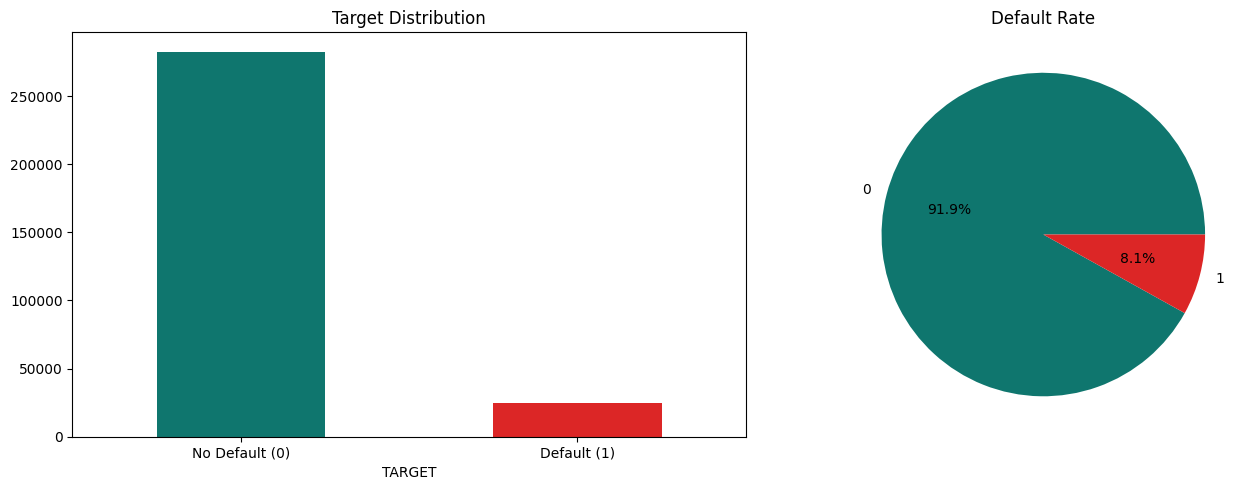

In [11]:
# Class imbalance visaulization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target Distribution
df['TARGET'].value_counts().plot(kind='bar', ax=axes[0], color=['#0f766e', '#dc2626'])
axes[0].set_title('Target Distribution')
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)

# Percentage
df['TARGET'].value_counts(normalize=True).plot(kind='pie', ax=axes[1], 
    autopct='%1.1f%%', colors=['#0f766e', '#dc2626'])
axes[1].set_title('Default Rate')

imbalance_ratio = df['TARGET'].value_counts()[0] / df['TARGET'].value_counts()[1]
print(f"Imbalance ratio: {imbalance_ratio:.1f}:1")
plt.tight_layout()
plt.savefig('../outputs/figures/target_distribution.png', dpi=150, bbox_inches='tight')

--- Step 1: Target Imbalance Analysis ---
No Default (0): 91.93%
Default (1): 8.07%
Imbalance Ratio: 11.4:1


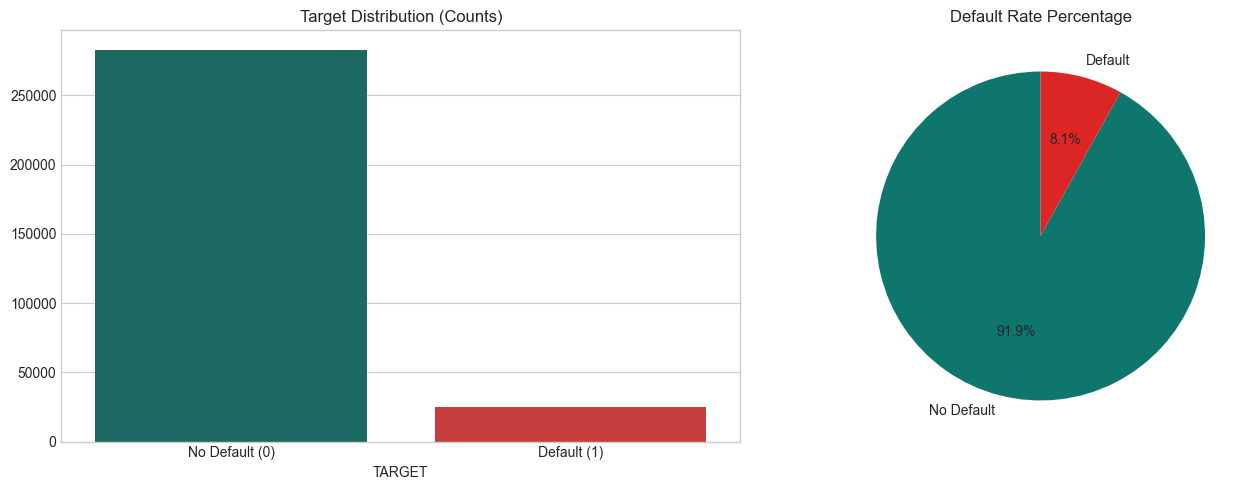

In [14]:
# Set global plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Load the dataset
df = pd.read_csv('../data/raw/application_train.csv')

# 1. Target Variable Distribution
print("--- Step 1: Target Imbalance Analysis ---")
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print(f"No Default (0): {target_pct[0]:.2f}%")
print(f"Default (1): {target_pct[1]:.2f}%")
print(f"Imbalance Ratio: {target_counts[0]/target_counts[1]:.1f}:1")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Plot
sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0], palette=['#0f766e', '#dc2626'])
axes[0].set_title('Target Distribution (Counts)')
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'])

# Pie Chart
axes[1].pie(target_pct, labels=['No Default', 'Default'], autopct='%1.1f%%', colors=['#0f766e', '#dc2626'], startangle=90)
axes[1].set_title('Default Rate Percentage')

plt.tight_layout()
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/target_distribution.png', dpi=150)
plt.show()

**TARGET DISTRIBUTION & CLASS IMBALANCE**
Neden? %8 default rate = 11:1 imbalance. Bu bilgi olmadan accuracy metriği bizi kandırır (%92 accuracy, hiç tahmin yapmadan). Interview'da mutlaka sorulur: "nasıl fark ettiniz?"

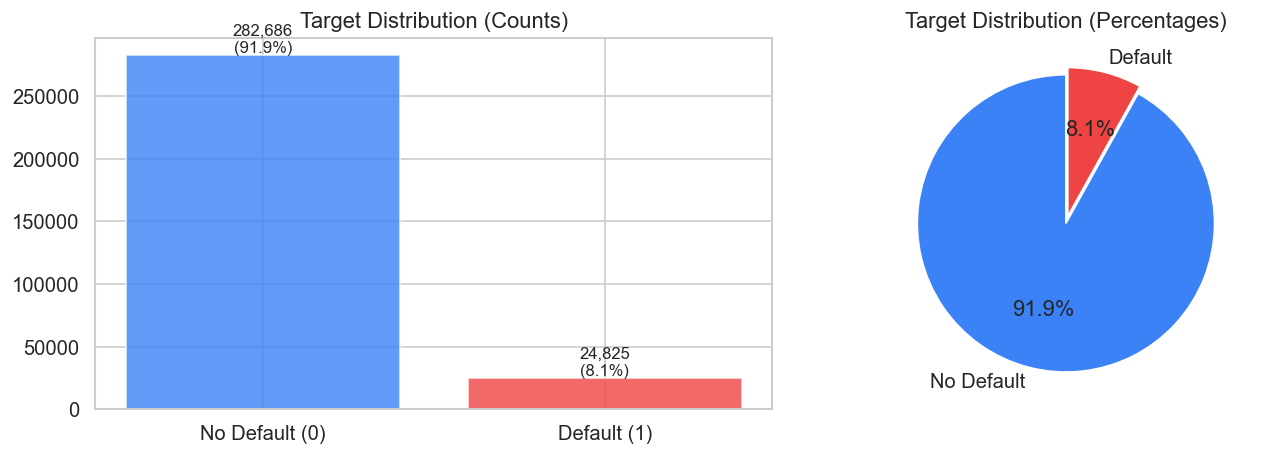


Imbalance ratio: 11.4:1
→ SMOTE veya class_weight='balanced' kullanmamız gerekecek


In [17]:
# Class imbalance - the main problem of the modeling phase. We will handle this in the next steps. But first, let's analyze the numeric variables.
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Bar chart
axes[0].bar(['No Default (0)', 'Default (1)'], target_counts, color=['#3b82f6', '#ef4444'], alpha=0.8)
axes[0].set_title('Target Distribution (Counts)')
for i, (count, pct) in enumerate(zip(target_counts, target_pct)):
    axes[0].text(i, count + 2000, f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=10)

# Right: Pie chart
axes[1].pie(target_counts, labels=['No Default', 'Default'], autopct='%1.1f%%', colors=['#3b82f6', '#ef4444'], startangle=90, explode=(0, 0.05))
axes[1].set_title('Target Distribution (Percentages)')

plt.tight_layout()
plt.show()

imbalance_ratio = target_counts[0] / target_counts[1]
print(f"\nImbalance ratio: {imbalance_ratio:.1f}:1")
print("→ SMOTE veya class_weight='balanced' kullanmamız gerekecek")







**MISSING DATA ANALYS**  Neden? Renkli eşik çizgileri ile hızlı karar: kırmızı = drop, sarı = impute stratejisi gerekli, mavi = basit fill. Bu grafiği Feature Engineering notebook'unda referans alacağız.

Missing data columns: 67
>%50 less: 41 columns → DROP candidates
5-50% less: 16 columns → impute
<%5 less: 10 columns → basic impute


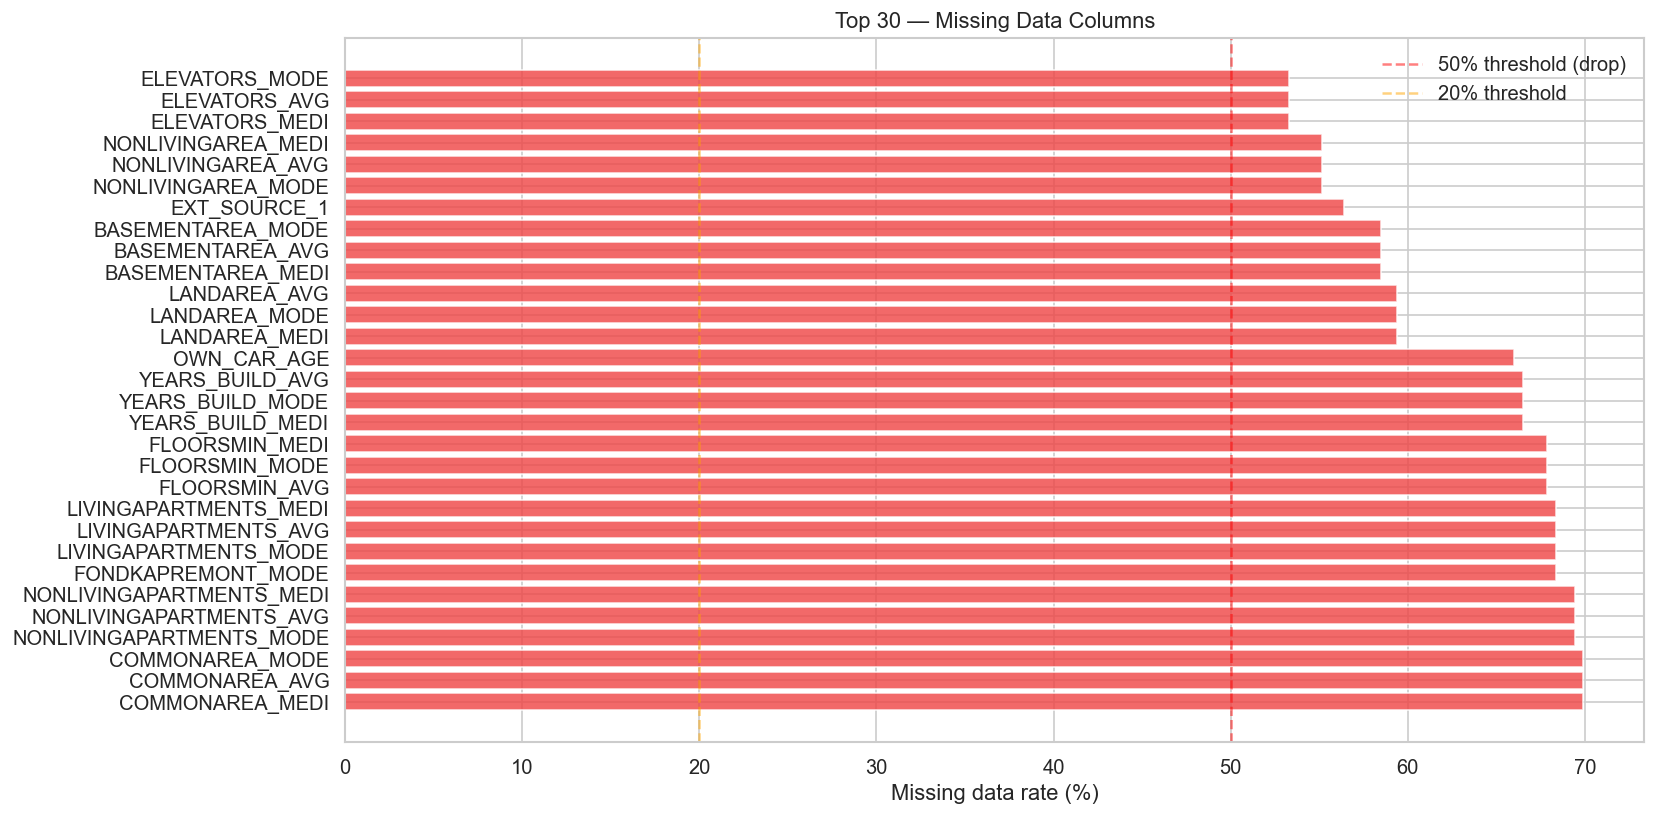


Drop 41 columns: ['COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG']...


In [23]:
# Missing data - do visualization for make a strategy for handling missing data. We will handle this in the next steps. But first, let's analyze the numeric variables.
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(), 
    'missing_pct': df.isnull().mean() * 100
}).sort_values(by='missing_pct', ascending=False)
missing = missing[missing['missing_pct'] > 0]

print(f"Missing data columns: {len(missing)}")
print(f">%50 less: {(missing['missing_pct'] > 50).sum()} columns → DROP candidates")
print(f"5-50% less: {((missing['missing_pct'] > 5) & (missing['missing_pct'] <= 50)).sum()} columns → impute")
print(f"<%5 less: {(missing['missing_pct'] <= 5).sum()} columns → basic impute")

# Visualization - just top 30 missing columns
top30 = missing.head(30)

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#ef4444' if x > 50 else '#f59e0b' if x > 20 else '#3b82f6' for x in top30['missing_pct']]
ax.barh(top30.index, top30['missing_pct'], color=colors, alpha=0.8)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold (drop)')
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='20% threshold')
ax.set_xlabel('Missing data rate (%)')
ax.set_title('Top 30 — Missing Data Columns')
ax.legend()
plt.tight_layout()
plt.show()

# Which columns to drop?
cols_to_drop = missing[missing['missing_pct'] > 50].index.tolist()
print(f"\nDrop {len(cols_to_drop)} columns: {cols_to_drop[:5]}...")

**Numeric Features Analysis** Neden? AMT_INCOME_TOTAL genellikle çok sağa çarpık olur (birkaç zengin outlier). Skewness > 1 görürsen Feature Engineering'de log transform uygularsın.

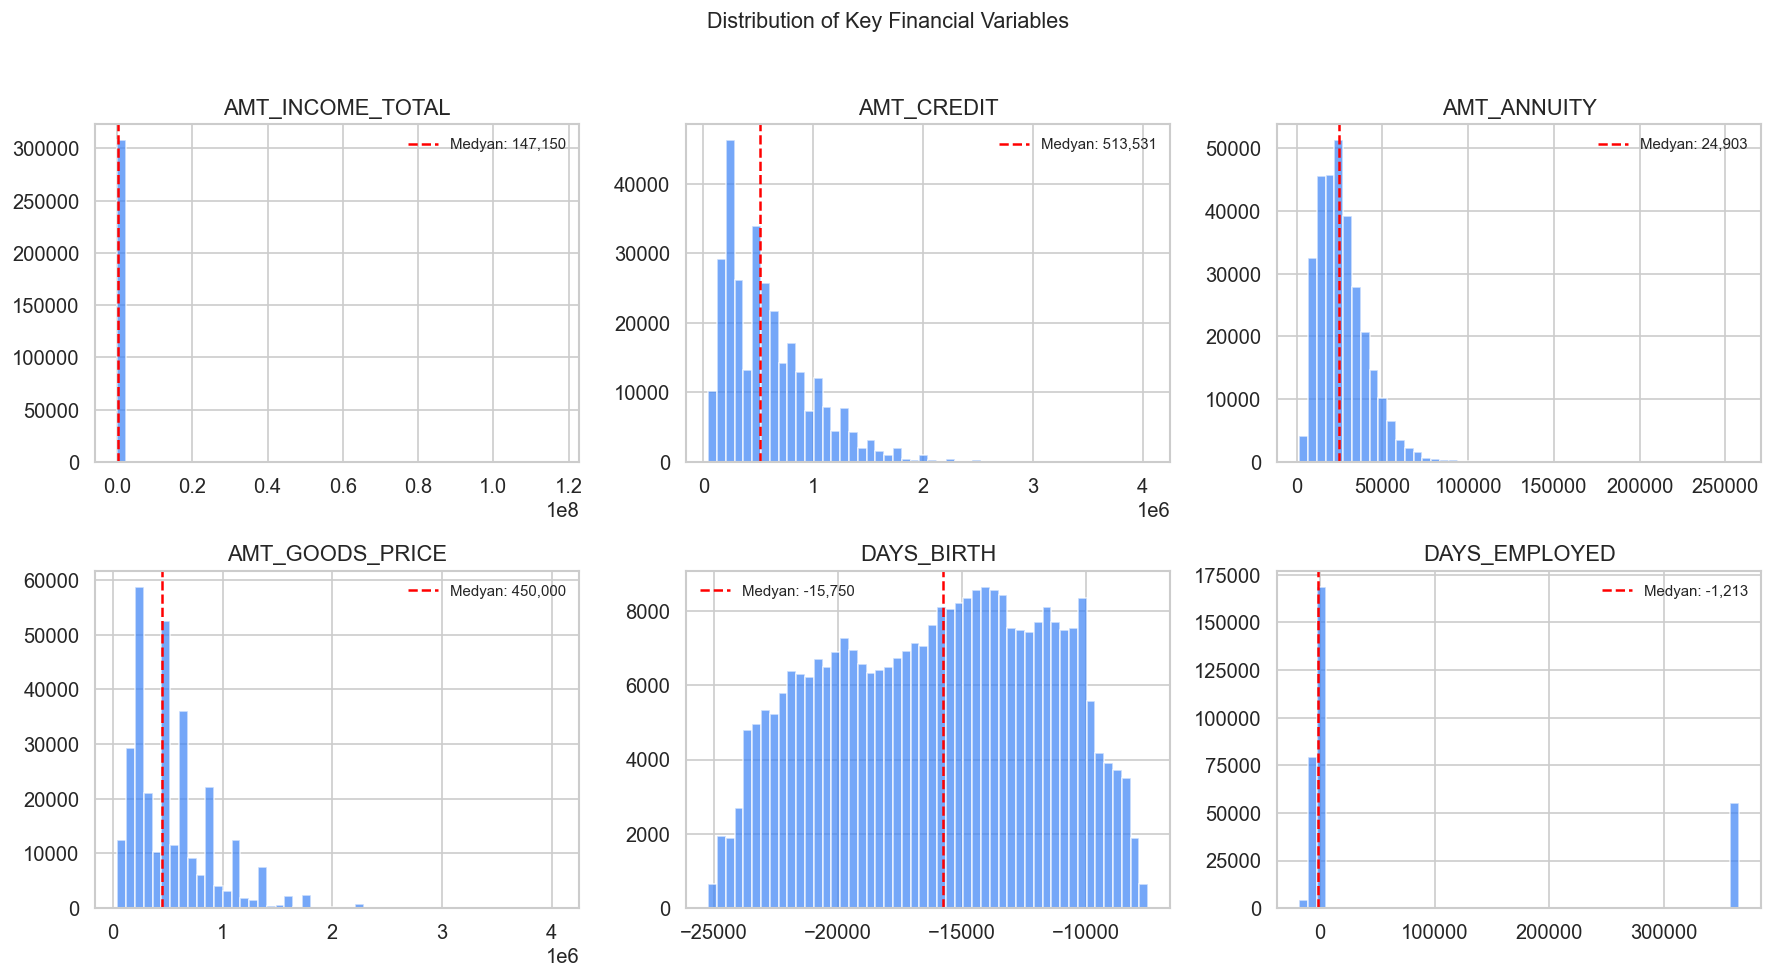

Skewness (if >1 or <-1, it's highly skewed):
AMT_INCOME_TOTAL    391.56
DAYS_EMPLOYED         1.66
AMT_ANNUITY           1.58
AMT_GOODS_PRICE       1.35
AMT_CREDIT            1.23
DAYS_BIRTH           -0.12
dtype: float64


In [ ]:
# Numeric columns analysis - we will handle this in the next steps. But first, let's analyze the numeric variables.
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'TARGET']

# Focus on important financial variables
key_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
key_cols = [c for c in key_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='#3b82f6', alpha=0.7, edgecolor='white')
    axes[i].axvline(data.median(), color='red', linestyle='--', label=f'Medyan: {data.median():,.0f}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=9)

plt.suptitle('Distribution of Key Financial Variables', y = 1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Skewness analysis - we will handle this in the next steps.
skew_df = df[key_cols].skew().sort_values(ascending=False)
print("Skewness (if >1 or <-1, it's highly skewed):")
print(skew_df.round(2))

High skewness (>2):
FLAG_DOCUMENT_12                392.114779
AMT_INCOME_TOTAL                391.559654
FLAG_DOCUMENT_10                209.589054
FLAG_DOCUMENT_2                 153.791817
AMT_REQ_CREDIT_BUREAU_QRT       134.365776
                                   ...    
YEARS_BEGINEXPLUATATION_MODE    -14.755318
YEARS_BEGINEXPLUATATION_AVG     -15.515264
YEARS_BEGINEXPLUATATION_MEDI    -15.573124
FLAG_CONT_MOBILE                -23.081172
FLAG_MOBIL                     -554.536744
Length: 71, dtype: float64


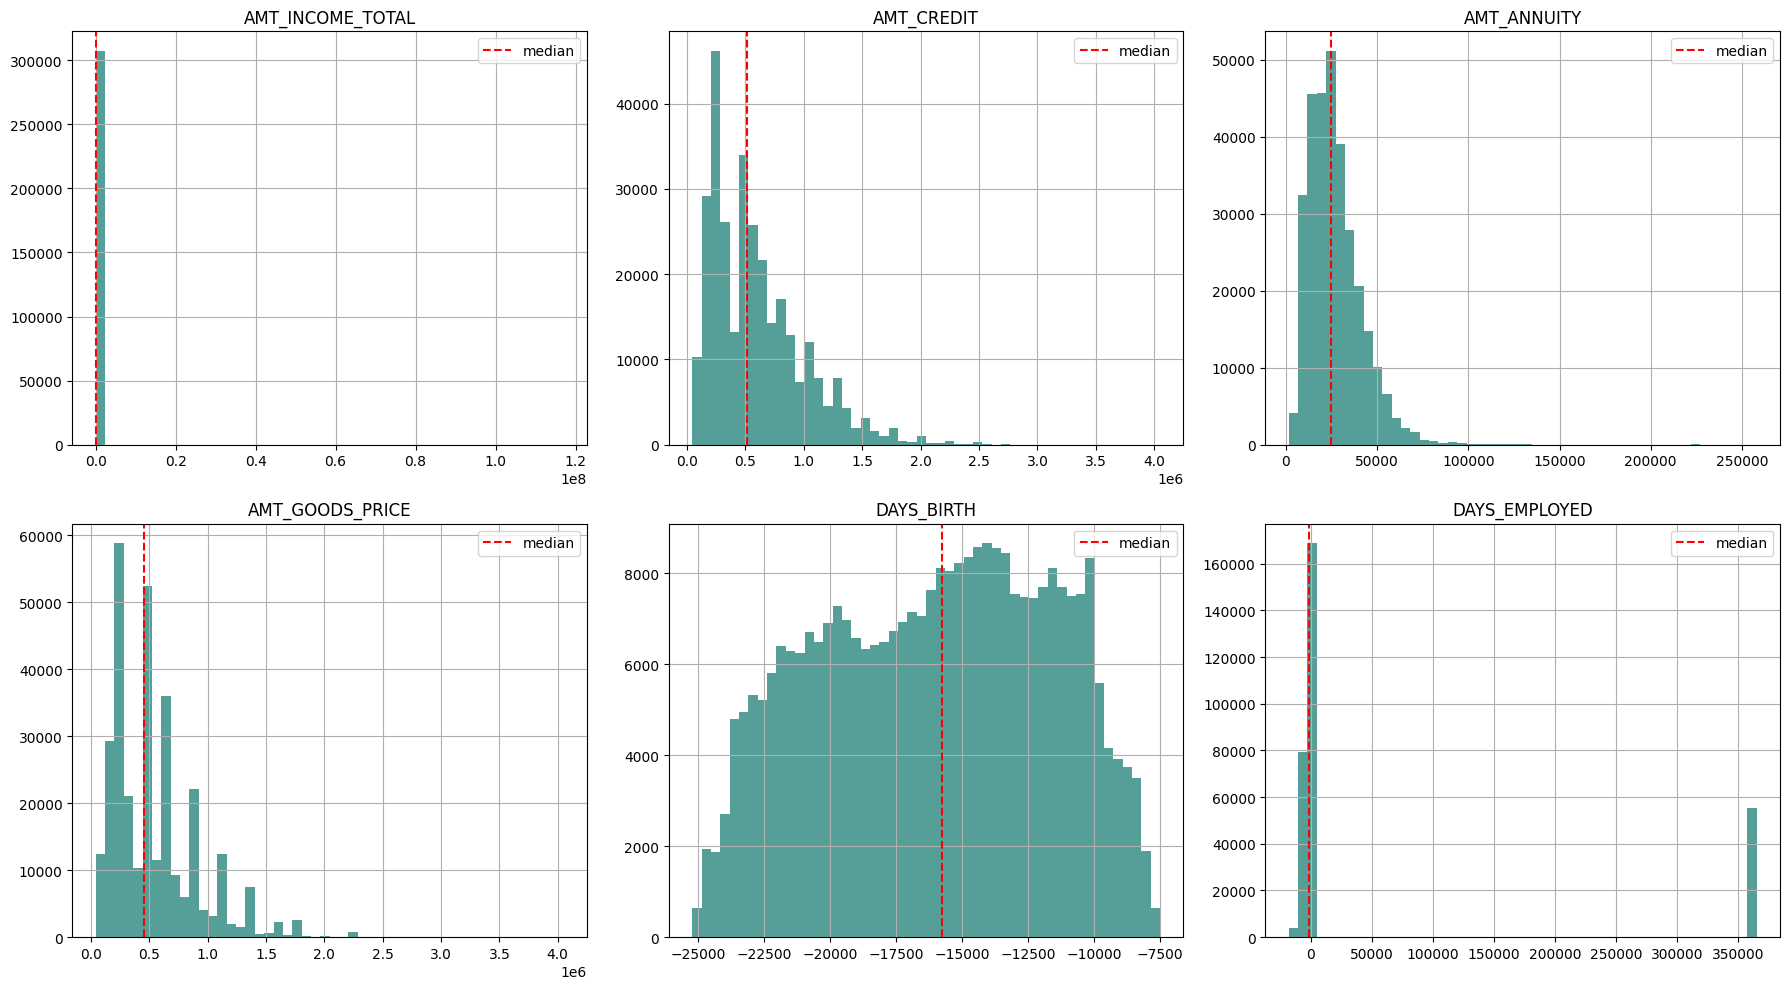

In [13]:
# Numeric variables analysis
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('TARGET')
num_cols.remove('SK_ID_CURR')

# Skewness analysis
skewness = df[num_cols].skew().sort_values(ascending=False)
print("High skewness (>2):")
print(skewness[skewness.abs() > 2])

# Distribution of selected variables
key_features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 
                'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(key_features):
    ax = axes[i//3, i%3]
    df[col].hist(bins=50, ax=ax, color='#0f766e', alpha=0.7)
    ax.set_title(col)
    ax.axvline(df[col].median(), color='red', linestyle='--', label='median')
    ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/numeric_distributions.png', dpi=150)

** Categorical Features & Target ** Neden? "Default rate by category" grafiği feature engineering'in temelidir. Kategoriler arasında büyük fark varsa WoE encoding güçlü olur. Interview sorusu: "hangi değişken en ayırt edici?"

Categorical columns: 16


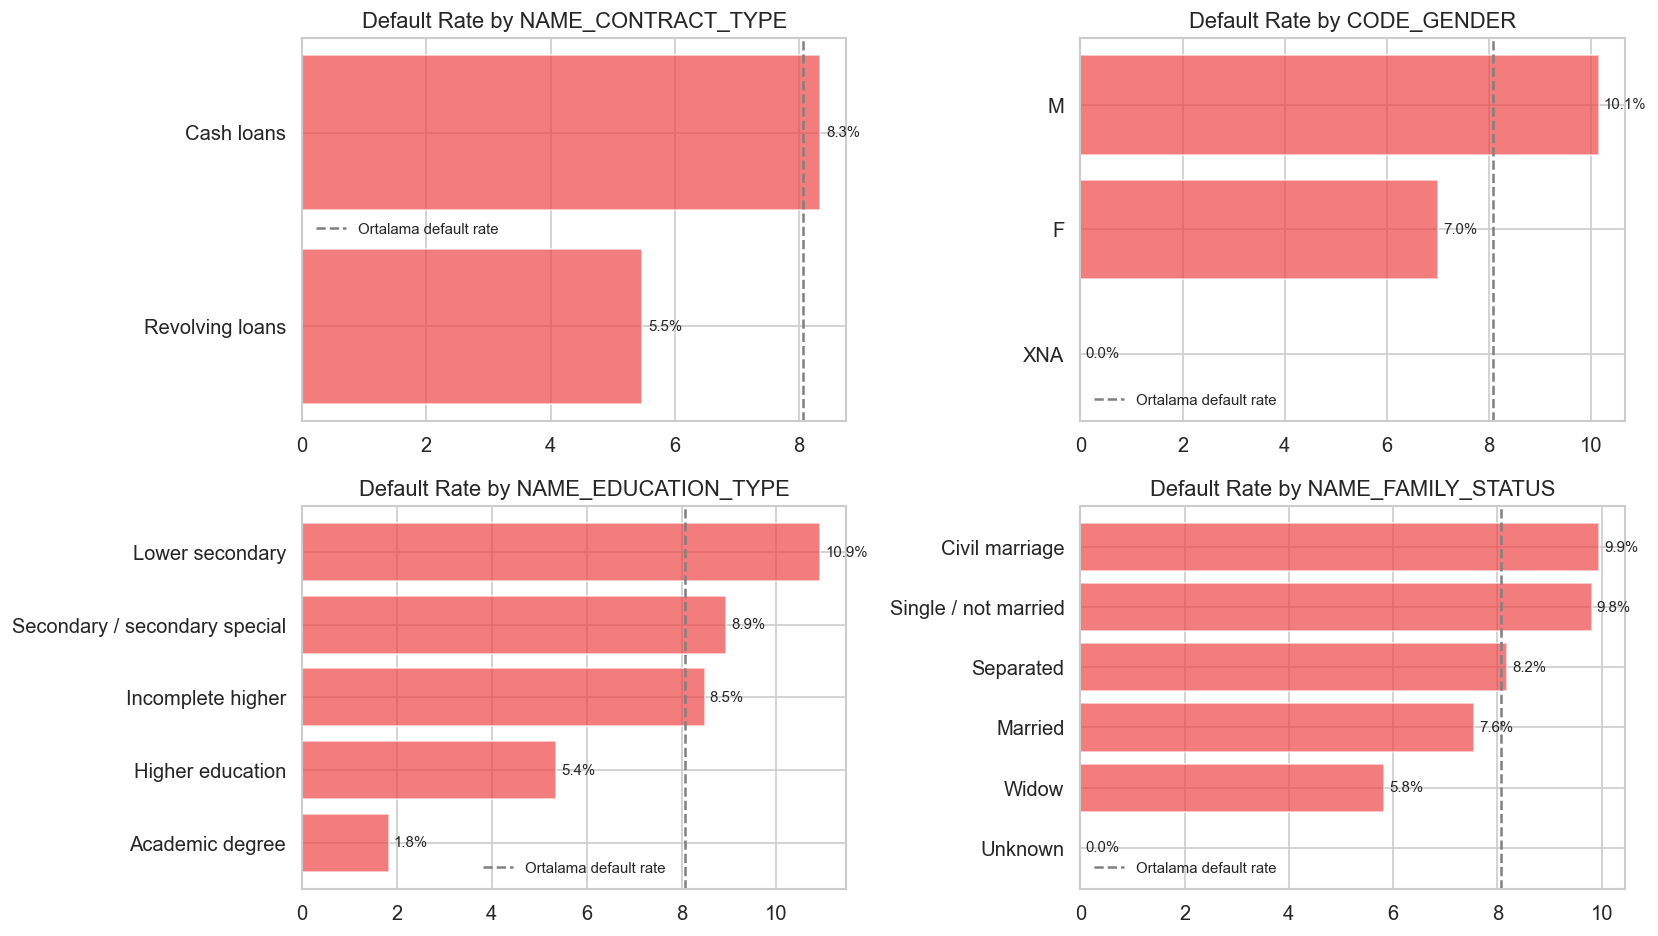

In [26]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {len(cat_cols)}")

# Calculate default rate by categorical variables
key_cat = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']
key_cat = [c for c in key_cat if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(key_cat):
    default_rate = df.groupby(col)['TARGET'].mean() * 100
    default_rate = default_rate.sort_values(ascending=True)

    bars = axes[i].barh(default_rate.index, default_rate, color='#ef4444', alpha=0.7)
    axes[i].axvline(x=df['TARGET'].mean() * 100, color='gray', linestyle='--', label='Ortalama default rate')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].legend(fontsize=9)
    for bar, val in zip(bars, default_rate):
        axes[i].text(val + 0.1, bar.get_y() + bar.get_height()/2, 
                    f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

** CORRELATION MATRIX ** Neden? Multicollinearity Logistic Regression'ı bozar. |r| > 0.85 olan çiftlerden birini drop etmek için bu bilgiyi Feature Engineering'e taşıyacağız.

TARGET ile en güçlü korelasyon (top 15):
EXT_SOURCE_3                   0.179
EXT_SOURCE_2                   0.160
EXT_SOURCE_1                   0.155
DAYS_BIRTH                     0.078
REGION_RATING_CLIENT_W_CITY    0.061
REGION_RATING_CLIENT           0.059
DAYS_LAST_PHONE_CHANGE         0.055
DAYS_ID_PUBLISH                0.051
REG_CITY_NOT_WORK_CITY         0.051
FLAG_EMP_PHONE                 0.046
DAYS_EMPLOYED                  0.045
REG_CITY_NOT_LIVE_CITY         0.044
FLAG_DOCUMENT_3                0.044
FLOORSMAX_AVG                  0.044
FLOORSMAX_MEDI                 0.044
Name: TARGET, dtype: float64


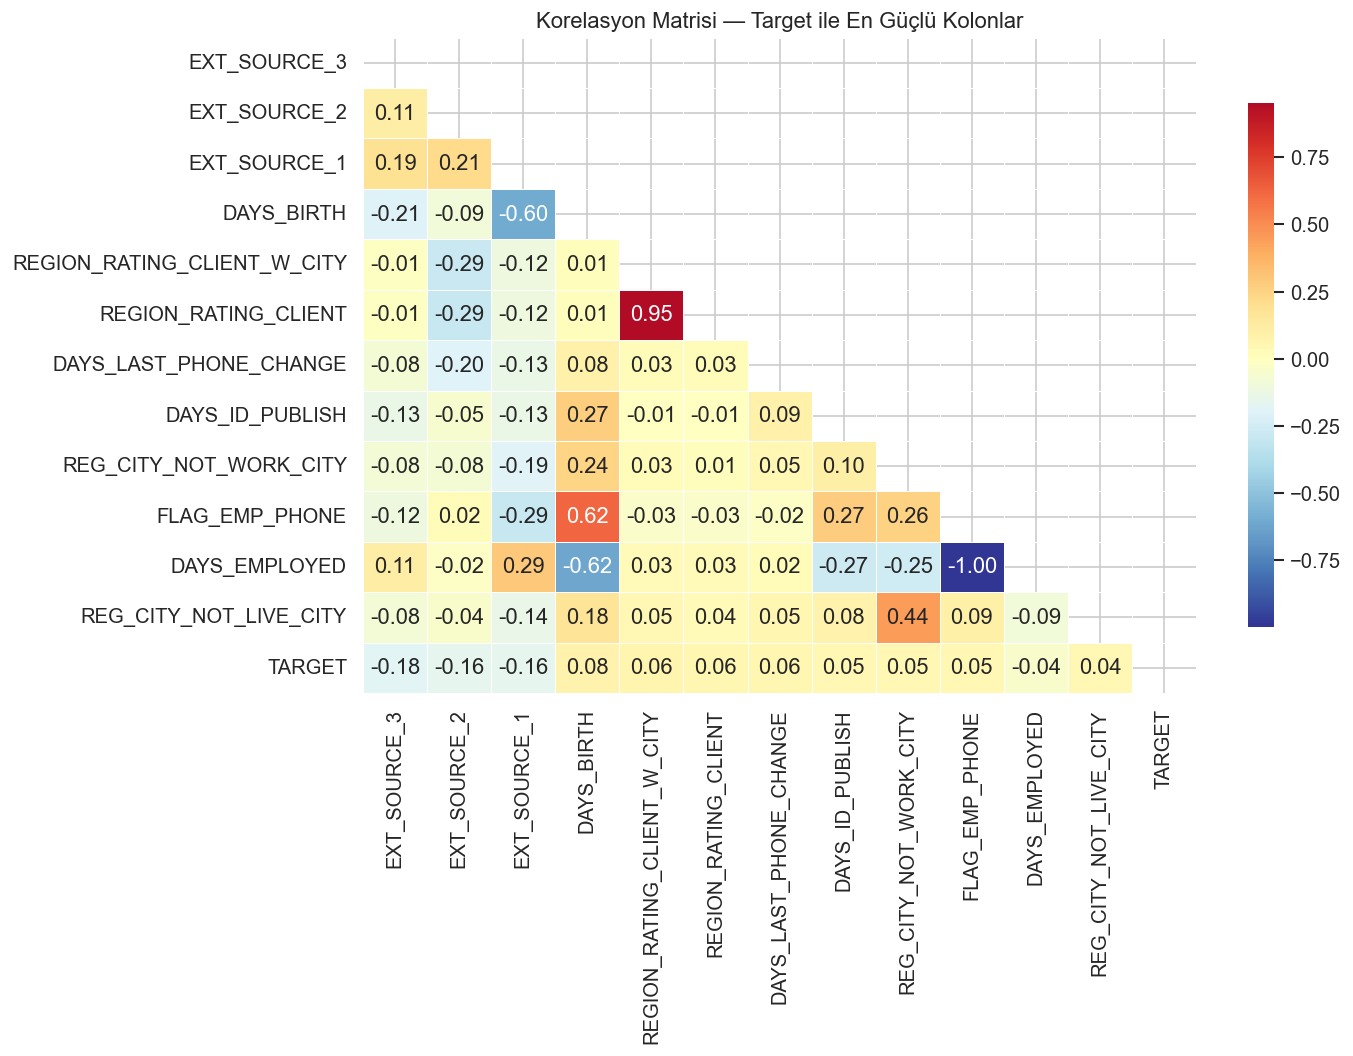


⚠ Yüksek korelasyonlu çift (>0.85) — Feature Eng'de birini drop et:
  REGION_RATING_CLIENT_W_CITY ↔ REGION_RATING_CLIENT: 0.951
  FLAG_EMP_PHONE ↔ DAYS_EMPLOYED: -1.0


In [28]:
# Which numerical variables correlate with TARGET? We will handle this in the next steps. But first, let's analyze the numeric variables.
corr_with_target = df[num_cols + ['TARGET']].corr()['TARGET'].drop('TARGET')
corr_with_target = corr_with_target.abs().sort_values(ascending=False)

print("TARGET ile en güçlü korelasyon (top 15):")
print(corr_with_target.head(15).round(3))

# Heatmap — top 12 kolon + TARGET
top_corr_cols = corr_with_target.head(12).index.tolist() + ['TARGET']
corr_matrix = df[top_corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Korelasyon Matrisi — Target ile En Güçlü Kolonlar')
plt.tight_layout()
plt.show()

# Multicollinearity uyarısı
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j]) > 0.85 and corr_matrix.columns[j] != 'TARGET':
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], 
                              round(corr_matrix.iloc[i,j], 3)))
if high_corr:
    print(f"\n⚠ Yüksek korelasyonlu çift (>0.85) — Feature Eng'de birini drop et:")
    for pair in high_corr:
        print(f"  {pair[0]} ↔ {pair[1]}: {pair[2]}")